# Transition Matrices or Monte Carlo: Which to Use When

By Christopher Carroll (ccarroll@llorracc.org), drawing on the experience of [Carroll, Crawley, Frankovic and Tretvoll (2026)](https://github.com/llorracc/HAFiscal), *Welfare and Spending Effects of Consumption Stimulus Policies*, whose computations use both methods.

HARK can push the distribution of households forward in two ways. **Monte Carlo (MC)** simulation tracks a finite panel of households, each drawing its own shocks. **Transition matrix (TM)** methods put the distribution on a grid and move it forward with a matrix built from the same policy functions and the same shock distributions. Both describe the same model; they differ in what they deliver and at what cost. The companion tutorial [`Transition_Matrix_Example.ipynb`](Transition_Matrix_Example.ipynb) explains the mechanics of the transition matrix approach in detail, including the Harmenberg (2021) income-weighted measure and grid design. This notebook is about the decision: which method, for which question.

## The short answer

**Use transition matrices when the object of interest is a property of the distribution**: a steady-state moment, a cross-sectional distribution, the aggregate response to a shock, or a Jacobian. The answer is deterministic, so it is smooth in the model's parameters and free of sampling noise; it is usually faster; and its only error is grid discretization, which you can measure and shrink.

**Use Monte Carlo when the object of interest depends on individual histories**: the realized path of a particular household, the distribution across households of gains that depend on what happened to each of them, or any statistic that conditions on a household's own experience (who was unemployed when the policy arrived, and for how long). A transition matrix carries the distribution of states, not the identity of the households in it, so it cannot pair a household's path under one policy with its path under another.

The HAFiscal paper is an example of both rules at once:

- **Estimation by TM.** The discount-factor distributions of its three education groups are estimated by matching the model's liquid-wealth distribution to the data. Each objective evaluation needs the model's steady state at a candidate parameter. Done by Monte Carlo, the objective is a noisy function of the parameters: it is jagged, with spurious local minima on which a local search stalls, and its minimizer moves from seed to seed. Done by transition matrix it is smooth, and the same estimates come out ten to twenty times faster. HAFiscal moved its estimation to the transition-matrix engine after a matched re-validation found the two engines' discount factors agreeing to within 0.06 percent.
- **Spending multipliers by TM.** The consumption response of the economy to a stimulus policy is a path of aggregates, exactly the object that forward propagation of a distribution delivers without noise.
- **Welfare by MC.** The paper's welfare measure compares, household by household, the consumption path each one experiences with the policy and without it, under the same shocks. That requires the histories, so it is done by Monte Carlo with common random numbers, at the price of sampling noise that has to be measured across seeds.

The rest of this notebook shows each point on HARK's default infinite-horizon consumer.

In [1]:
from copy import deepcopy
from time import time

import matplotlib.pyplot as plt
import numpy as np

from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType

# HARK's default infinite-horizon consumer: permanent and transitory income shocks,
# 2 percent quarterly mortality, and no aggregate trend (PermGroFacAgg = 1, so every
# newborn cohort starts at the same level and the economy's size is stationary).
base = IndShockConsumerType(cycles=0)
base.solve()

# Grids for the transition matrix: the arrival state (capital) and two outcomes.
GRIDS = {
    "kNrm": {"min": 0.0, "max": 40.0, "N": 120, "order": 2.0},
    "aNrm": {"min": 0.0, "max": 40.0, "N": 120, "order": 2.0},
    "cNrm": {"min": 0.0, "max": 8.0, "N": 101},
}


def tm_long_run(agent, var="aNrm"):
    """The long-run (steady-state) average of an outcome by transition matrix, under the
    income-weighted measure (norm='G'): the aggregate per unit of aggregate permanent income."""
    a = deepcopy(agent)
    a.initialize_sym()
    X = a._simulator
    X.make_transition_matrices(GRIDS, norm="G")
    X.find_steady_state()
    return float(X.get_long_run_average(var))


def mc_long_run(agent, var="aNrm", seed=0, agent_count=10_000, T_sim=300, T_keep=100):
    """The same average by Monte Carlo: simulate a panel, weight each household by its
    permanent income (the income-weighted measure again), average the last T_keep periods."""
    a = deepcopy(agent)
    a.AgentCount, a.T_sim, a.seed = agent_count, T_sim, seed
    a.track_vars = ["pLvl", var]
    a.initialize_sim()
    a.simulate()
    P = a.history["pLvl"][-T_keep:]
    V = a.history[var][-T_keep:]
    return float(np.sum(P * V) / np.sum(P))

## 1. One number, two ways

The long-run average of normalized assets, first by transition matrix and then by Monte Carlo with a panel of ten thousand households, five times with different seeds.

In [2]:
t0 = time()
A_tm = tm_long_run(base)
t_tm = time() - t0

t0 = time()
A_mc = np.array([mc_long_run(base, seed=s) for s in range(5)])
t_mc = (time() - t0) / 5

print(f"transition matrix: A = {A_tm:.4f}   ({t_tm:.1f} s, one deterministic number)")
print(
    f"Monte Carlo, 5 seeds: A = {A_mc.mean():.4f} +- {A_mc.std(ddof=1):.4f} "
    f"(seed to seed; {t_mc:.1f} s per seed)"
)
print("Monte Carlo by seed:", np.round(A_mc, 4))
print(
    f"TM minus MC mean: {A_tm - A_mc.mean():+.4f}  ({(A_tm / A_mc.mean() - 1) * 100:+.2f} percent)"
)

transition matrix: A = 0.5170   (1.4 s, one deterministic number)
Monte Carlo, 5 seeds: A = 0.5145 +- 0.0021 (seed to seed; 1.1 s per seed)
Monte Carlo by seed: [0.5149 0.5118 0.5135 0.5145 0.5177]
TM minus MC mean: +0.0025  (+0.49 percent)


The two agree on the level to within the Monte Carlo spread. The difference in kind is what matters: the transition-matrix number is a single deterministic value, while the Monte Carlo number carries a seed-to-seed standard deviation that shrinks only as $1/\sqrt{N}$. Halving it costs four times the households and four times the time.

## 2. Estimation: a smooth objective or a noisy one

Suppose the discount factor is to be estimated by matching the long-run average of assets to a target. Take the target to be the transition-matrix answer at $\beta = 0.96$, so that the true value is known, and evaluate the objective $(A(\beta) - A^{*})^2$ once by transition matrix and once by Monte Carlo with three different seeds, on a panel of four thousand households (an estimator has to keep each evaluation affordable). Two grids of candidates: a coarse one across the plausible range, and a fine one around the optimum, at the resolution an optimizer works at in its last steps.

63 s for both grids, both methods


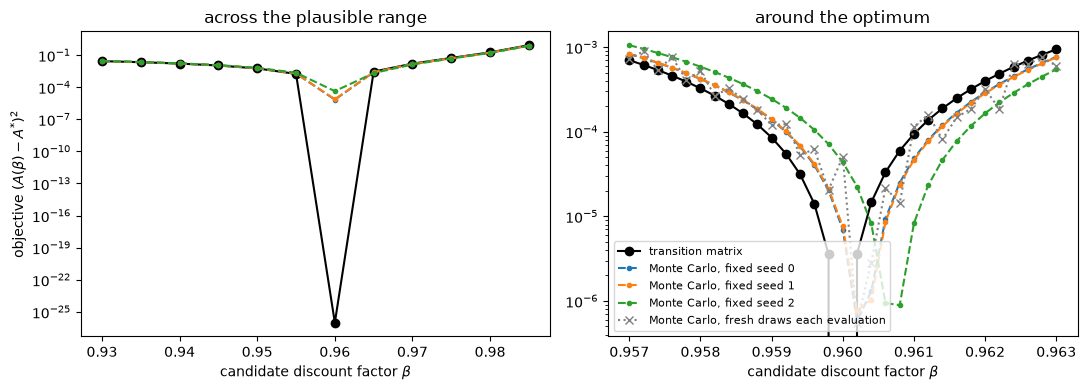

target A* = 0.5170 at beta = 0.9600
TM: minimizer beta = 0.95999, 1 local minimum on the fine grid
MC seed 0: minimizer beta = 0.96027, 1 local minima on the fine grid
MC seed 1: minimizer beta = 0.96028, 1 local minima on the fine grid
MC seed 2: minimizer beta = 0.96069, 1 local minima on the fine grid
MC fresh draws, run 0: grid argmin beta = 0.9602, 11 local minima on the fine grid
MC fresh draws, run 1: grid argmin beta = 0.9602, 9 local minima on the fine grid
MC fresh draws, run 2: grid argmin beta = 0.9602, 10 local minima on the fine grid
MC minimizers: mean 0.96041 (offset +0.00041 from the truth, the level difference of Section 1 divided by dA/dbeta = 9.47), seed-to-seed SD 0.00024; MC noise in A 0.0019 (4,000 households) is 0.0002 in beta


In [3]:
def agent_at(beta):
    a = deepcopy(base)
    a.DiscFac = float(beta)
    a.solve()
    return a


def objective_inputs(
    betas, seeds=(0, 1, 2), agent_count=4_000, T_sim=150, T_keep=50, fresh_draws=False
):
    # Long-run assets by TM and by MC for each candidate beta (one solve per beta). With a
    # fixed seed the same shocks serve every candidate (common random numbers); with
    # fresh draws each evaluation gets its own, as when evaluations run independently.
    A_tm, A_mc = [], []
    for j, b in enumerate(betas):
        a = agent_at(b)
        A_tm.append(tm_long_run(a))
        A_mc.append(
            [
                mc_long_run(
                    a,
                    seed=(1000 * s + j if fresh_draws else s),
                    agent_count=agent_count,
                    T_sim=T_sim,
                    T_keep=T_keep,
                )
                for s in seeds
            ]
        )
    return np.array(A_tm), np.array(A_mc).T


t0 = time()
coarse = np.linspace(0.930, 0.985, 12)
fine = np.linspace(
    0.957, 0.963, 31
)  # steps of 0.0002, the resolution of an optimizer's last iterations
A_tm_c, A_mc_c = objective_inputs(coarse)
A_tm_f, A_mc_f = objective_inputs(fine)
_, A_mc_fresh = objective_inputs(fine, agent_count=2_000, fresh_draws=True)
print(f"{time() - t0:.0f} s for both grids, both methods")

i_true = int(np.argmin(np.abs(fine - 0.96)))
target = float(A_tm_f[i_true])  # the TM answer at beta = 0.96 exactly

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, grid, A_tm, A_mc, title in [
    (axes[0], coarse, A_tm_c, A_mc_c, "across the plausible range"),
    (axes[1], fine, A_tm_f, A_mc_f, "around the optimum"),
]:
    ax.plot(grid, (A_tm - target) ** 2, "k-o", label="transition matrix")
    for k in range(A_mc.shape[0]):
        ax.plot(
            grid,
            (A_mc[k] - target) ** 2,
            "--",
            marker=".",
            label=f"Monte Carlo, fixed seed {k}",
        )
    if grid is fine:
        ax.plot(
            grid,
            (A_mc_fresh[0] - target) ** 2,
            ":",
            color="gray",
            marker="x",
            label="Monte Carlo, fresh draws each evaluation",
        )
    ax.set_yscale("log")
    ax.set_xlabel(r"candidate discount factor $\beta$")
    ax.set_title(title)
axes[0].set_ylabel(r"objective $(A(\beta) - A^{*})^2$")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


def vertex(grid, obj, half_width=4):
    # The continuous minimizer: the vertex of a quadratic fitted around the grid minimum.
    i = int(np.argmin(obj))
    lo, hi = max(0, i - half_width), min(len(grid), i + half_width + 1)
    a2, a1, _ = np.polyfit(grid[lo:hi], obj[lo:hi], 2)
    return -a1 / (2 * a2)


def local_minima(obj):
    # Interior grid points lower than both neighbours.
    return int(np.sum((obj[1:-1] < obj[:-2]) & (obj[1:-1] < obj[2:])))


slope = float(
    np.gradient(A_tm_f, fine)[i_true]
)  # dA/dbeta at the optimum, from the TM curve
noise = float(
    np.std(A_mc_f - A_tm_f, ddof=1)
)  # the MC noise in A, pooled over the fine grid
obj_tm_f = (A_tm_f - target) ** 2
print(f"target A* = {target:.4f} at beta = {fine[i_true]:.4f}")
print(
    f"TM: minimizer beta = {vertex(fine, obj_tm_f):.5f}, {local_minima(obj_tm_f)} local minimum on the fine grid"
)
mins = []
for k in range(A_mc_f.shape[0]):
    obj = (A_mc_f[k] - target) ** 2
    mins.append(vertex(fine, obj))
    print(
        f"MC seed {k}: minimizer beta = {mins[-1]:.5f}, {local_minima(obj)} local minima on the fine grid"
    )
mins = np.array(mins)
for k in range(A_mc_fresh.shape[0]):
    obj = (A_mc_fresh[k] - target) ** 2
    print(
        f"MC fresh draws, run {k}: grid argmin beta = {fine[np.argmin(obj)]:.4f}, {local_minima(obj)} local minima on the fine grid"
    )
print(
    f"MC minimizers: mean {mins.mean():.5f} (offset {mins.mean() - 0.96:+.5f} from the truth, the level difference "
    f"of Section 1 divided by dA/dbeta = {slope:.2f}), seed-to-seed SD {mins.std(ddof=1):.5f}; "
    f"MC noise in A {noise:.4f} (4,000 households) is {noise / slope:.4f} in beta"
)

Across the plausible range the two methods agree, because the objective changes far more between candidates than the noise. Around the optimum the picture reverses. The transition-matrix objective is a smooth curve with one minimum at the true value. Monte Carlo fails in one of two ways, and the figure shows both. Holding the seed fixed across candidates (common random numbers, the standard remedy) keeps the objective smooth, but its minimizer then depends on the seed: the three seeds place it at different values, scattered by the amount printed above, and all a little above the truth by a common offset that is not noise but the level difference between the two methods seen in Section 1, divided by the slope of the objective. Drawing fresh shocks for each evaluation, as happens whenever evaluations run independently, removes the dependence on any one seed at the price of a jagged objective with several local minima, at any of which a gradient-based or pattern-search optimizer stops. Either way the estimator cannot tell candidates apart inside the noise band, and the only cure is a larger panel, at a cost that grows with the square of the precision wanted. The transition matrix's error is different in kind: a fixed discretization bias that a finer grid shrinks and that a Monte Carlo benchmark can measure. HAFiscal estimated its discount factors by Monte Carlo through the paper and moved to the transition-matrix engine in June 2026, after a matched re-validation found the two engines' estimates within 0.06 percent of each other, with the transition-matrix engine ten to twenty times faster.

## 3. Aggregate responses

A spending multiplier is a path of aggregate consumption relative to a baseline, per unit of stimulus. Forward propagation of the distribution delivers such paths exactly, and HARK's sequence-space Jacobian tools (`make_basic_SSJ`, `calc_impulse_response_manually`; see [`SSJ-tutorial.ipynb`](SSJ-tutorial.ipynb)) build them from the transition matrices. By Monte Carlo the same path is a difference between two noisy aggregates, and its signal has to clear the panel's noise floor. The cell below computes the exact consumption response to a one-period interest-rate shock by transition matrix and sets its size against the Monte Carlo noise measured in Section 1.

In [4]:
resp = deepcopy(base).calc_impulse_response_manually(
    "Rfree", "cNrm", GRIDS, s=0, norm="G", offset=True, solved=True
)
C_tm = tm_long_run(base, "cNrm")
C_mc = np.array([mc_long_run(base, "cNrm", seed=s) for s in range(5)])

peak = float(np.max(np.abs(resp)))
print(
    f"long-run consumption: TM {C_tm:.4f}; MC seed-to-seed SD {C_mc.std(ddof=1):.5f} (10,000 households)"
)
print(
    f"peak consumption response to a unit interest-factor shock at t=0 (TM, exact): {peak:.4f}"
)
print(
    "a one-percentage-point shock moves consumption by about "
    f"{peak * 0.01:.5f} at the peak, against a Monte Carlo noise floor of {C_mc.std(ddof=1):.5f} per seed"
)

long-run consumption: TM 1.0049; MC seed-to-seed SD 0.00059 (10,000 households)
peak consumption response to a unit interest-factor shock at t=0 (TM, exact): 0.1654
a one-percentage-point shock moves consumption by about 0.00165 at the peak, against a Monte Carlo noise floor of 0.00059 per seed


The response to a realistic shock is of the same order as the seed-to-seed noise of a ten-thousand-household panel, so a Monte Carlo estimate of the path would need common random numbers across the two simulations and a panel one to two orders of magnitude larger to trace the path cleanly. The transition matrix gives it directly. HAFiscal's multipliers are computed this way, by propagating the distribution through the recession with and without the policy.

## 4. Histories: what only Monte Carlo can give you

Now a question that a transition matrix cannot answer. Let the panel reach its long-run distribution, then give every household a one-time transfer equal to ten percent of average quarterly permanent income, and ask what each household gains in welfare over the following five years, measured as the constant percentage increase in its baseline consumption path that would leave it as well off as the transfer does. The gain differs across households, because a household with little wealth consumes the transfer while a wealthy one barely notices it, and it depends on the shocks each household receives afterwards. To compute it, simulate the same households under the same shocks twice, with and without the transfer, and compare their paths one by one. Common random numbers come free: the same seed reproduces the same draws.

transfer: 0.184 per household (10 percent of average permanent income 1.84)
consumption-equivalent welfare gain from the transfer, percent of baseline consumption
  all households: mean 1.260, median 1.041, 5th to 95th percentile 0.150 to 3.076
  wealth quintile 1: mean gain 2.680  (market resources 0.82)
  wealth quintile 2: mean gain 1.456  (market resources 1.30)
  wealth quintile 3: mean gain 1.073  (market resources 1.75)
  wealth quintile 4: mean gain 0.747  (market resources 2.51)
  wealth quintile 5: mean gain 0.345  (market resources 7.59)


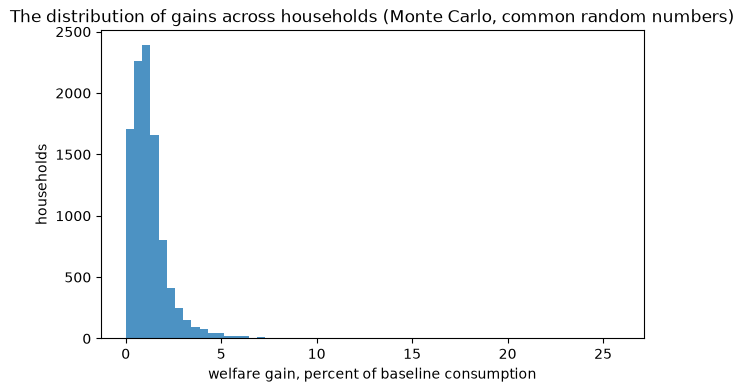

In [5]:
T_BURN, T_AFTER = 200, 20  # reach the long-run distribution, then follow five years


def simulate_paths(agent, transfer_level=0.0, seed=0, agent_count=10_000):
    # Consumption levels of a panel from the transfer date on, plus market resources and
    # permanent income at that date. The transfer (a level, the same for every household)
    # arrives with income in period T_BURN.
    a = deepcopy(agent)
    a.AgentCount, a.T_sim, a.seed = agent_count, T_BURN + T_AFTER, seed
    a.track_vars = ["cNrm", "pLvl", "mNrm"]
    a.initialize_sim()
    if transfer_level > 0.0:
        base_get_shocks = a.get_shocks

        def get_shocks_with_transfer():
            base_get_shocks()
            if a.t_sim == T_BURN:
                pLvl_now = a.state_prev["pLvl"] * a.shocks["PermShk"]
                a.shocks["TranShk"] = a.shocks["TranShk"] + transfer_level / pLvl_now

        a.get_shocks = get_shocks_with_transfer
    a.simulate()
    cLvl = (a.history["cNrm"] * a.history["pLvl"])[T_BURN:]
    return cLvl, a.history["mNrm"][T_BURN].copy(), a.history["pLvl"][T_BURN].copy()


rho, disc = float(base.CRRA), float(base.DiscFac)
c0, m0, p0 = simulate_paths(base)
transfer = 0.10 * float(p0.mean())
c1, _, _ = simulate_paths(base, transfer_level=transfer)
print(
    f"transfer: {transfer:.3f} per household (10 percent of average permanent income {p0.mean():.2f})"
)

# discounted utility of each household's path over the window, and the consumption-equivalent gain
w = disc ** np.arange(c0.shape[0])[:, None]


def U(c):
    return np.sum(w * c ** (1.0 - rho) / (1.0 - rho), axis=0)


gain_pct = ((U(c1) / U(c0)) ** (1.0 / (1.0 - rho)) - 1.0) * 100.0

wealth = m0 * p0  # market resources in levels at the transfer date
quintile = np.digitize(wealth, np.quantile(wealth, [0.2, 0.4, 0.6, 0.8]))
print(
    "consumption-equivalent welfare gain from the transfer, percent of baseline consumption"
)
print(
    f"  all households: mean {gain_pct.mean():.3f}, median {np.median(gain_pct):.3f}, "
    f"5th to 95th percentile {np.percentile(gain_pct, 5):.3f} to {np.percentile(gain_pct, 95):.3f}"
)
for q in range(5):
    sel = quintile == q
    print(
        f"  wealth quintile {q + 1}: mean gain {gain_pct[sel].mean():.3f}  (market resources {wealth[sel].mean():.2f})"
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gain_pct, bins=60, color="tab:blue", alpha=0.8)
ax.set_xlabel("welfare gain, percent of baseline consumption")
ax.set_ylabel("households")
ax.set_title(
    "The distribution of gains across households (Monte Carlo, common random numbers)"
)
plt.show()

Every number above is a statistic of paired individual histories: a household's gain is the comparison of *its* two paths. A transition matrix could give the two cross-sectional distributions of consumption in each period, and even the change in expected value integrated against the value function, but not the distribution of realized gains, not the gains of the households who happened to lose their jobs in the quarter after the transfer, and not any other statistic that conditions on a household's own experience. HAFiscal's welfare numbers are of this kind, which is why they are the one part of that paper computed by Monte Carlo, with the seed-to-seed noise reported alongside.

## Rule of thumb

| Question | Method | Why |
|---|---|---|
| Steady-state moments and distributions | TM | deterministic, smooth in parameters, grid error measurable |
| Estimation by matching moments | TM | a Monte Carlo objective is noisy in the parameters; its noise floor defeats the optimizer |
| Aggregate responses, multipliers, Jacobians | TM | exact propagation of the distribution; Monte Carlo would difference two noisy aggregates |
| Realized paths, ex-post distributions of gains, statistics conditioning on a household's history | MC | the transition matrix carries the distribution, not the households |
| Checking a transition-matrix grid | both | Monte Carlo is the unbiased benchmark for discretization error |

For the mechanics of the transition-matrix approach, grid design and the income-weighted measure, see [`Transition_Matrix_Example.ipynb`](Transition_Matrix_Example.ipynb); for Jacobians and impulse responses, [`SSJ-tutorial.ipynb`](SSJ-tutorial.ipynb). For the paper whose practice this notebook distills, see the [HAFiscal repository](https://github.com/llorracc/HAFiscal).